In [1]:
import os
import time
import numpy as np
import seaborn as sns
from numpy.polynomial.legendre import leggauss
from matplotlib import pyplot as plt

In [2]:
sns.set_theme(style="whitegrid")

In [3]:
folder = "./discontinuousGalerkinFEM"

if not os.path.isdir(folder):
    os.mkdir(folder)
else:
    print("directory " + folder + " already created")

folder = folder + "/trabalho2_"

directory ./discontinuousGalerkinFEM already created


In [4]:
# Definindo as funções exatas
def exact_u(x):
    return np.sin(np.pi * x)

def exact_f(x):
    return (np.pi**2) * np.sin(np.pi * x)


In [5]:
# Função de criação de malha

def create_mesh(l, n_elem):
    nodes = np.linspace(0, l, n_elem+1)
    elements = np.array([[i, i+1] for i in range(n_elem)])
    return nodes, elements

In [6]:
def lagrange_shape(k, xi):
    # Aqui faço N e dN/dxi para elemento de grau k no intervalo [-1, 1]
    xi_nodes = np.linspace(-1, 1, k + 1)

    N = np.zeros(k + 1)
    dN_dxi = np.zeros(k + 1)

    for i in range(k + 1):
        p_val = 1.0

        for j in range(k + 1):
            if i != j:
                p_val *= (xi - xi_nodes[j]) / (xi_nodes[i] - xi_nodes[j])

        N[i] = p_val

        dp_val = 0.0

        for j in range(k + 1):
            if i != j:
                term = 1.0 / (xi_nodes[i] - xi_nodes[j])

                for m in range(k + 1):
                    if m != i and m != j:
                        term *= (xi - xi_nodes[m]) / (xi_nodes[i] - xi_nodes[m])

                dp_val += term

        dN_dxi[i] = dp_val

    return N, dN_dxi

# Aqui estou redefinindo o hibrido só para fazer o teste!

In [7]:
def local_matrices_hybrid(x1, x2, k, alpha, beta):
    h = x2 - x1
    J = h / 2.0

    n_loc_nodes = k + 1

    A_loc = np.zeros((n_loc_nodes, n_loc_nodes))
    B_loc = np.zeros((n_loc_nodes, 2))
    D_loc = np.zeros((2, n_loc_nodes))
    C_loc = np.zeros((2, 2))
    F_loc = np.zeros(n_loc_nodes)

    # Integração dos termos de volume
    gauss_pts, weights = leggauss(k + 2)

    x_coords = np.linspace(x1, x2, k + 1)

    for gp, w in zip(gauss_pts, weights):
        N, dN_dxi = lagrange_shape(k, gp)
        dN_dx = dN_dxi / J

        x_gp = np.dot(N, x_coords)
        f_val = exact_f(x_gp)

        for i in range(n_loc_nodes):
            F_loc[i] += f_val * N[i] * w * J

            for j in range(n_loc_nodes):
                A_loc[i, j] += dN_dx[i] * dN_dx[j] * w * J

    # Termos de fronteira locais
    # Em 1D:
    # ponto esquerdo: normal = -1
    # ponto direito: normal =  1

    boundary_data = [
        {"xi": -1.0, "normal": -1.0, "lambda_index": 0},
        {"xi":  1.0, "normal":  1.0, "lambda_index": 1}
    ]

    for bd in boundary_data:
        xi_b = bd["xi"]
        normal = bd["normal"]
        lambda_index = bd["lambda_index"]

        N_b, dN_dxi_b = lagrange_shape(k, xi_b)
        dN_dx_b = dN_dxi_b / J

        for i in range(n_loc_nodes):      # função teste v
            for j in range(n_loc_nodes):  # função tentativa u

                # A:
                # int u' v'
                # - int_boundary u' n v
                # + alpha int_boundary v' n u
                # + beta int_boundary u v

                A_loc[i, j] += -dN_dx_b[j] * normal * N_b[i]
                A_loc[i, j] += alpha * dN_dx_b[i] * normal * N_b[j]
                A_loc[i, j] += beta * N_b[j] * N_b[i]

            # B:
            # - alpha int_boundary v' n lambda
            # - beta int_boundary lambda v

            B_loc[i, lambda_index] += -alpha * dN_dx_b[i] * normal
            B_loc[i, lambda_index] += -beta * N_b[i]

        for j in range(n_loc_nodes):      # função tentativa u
            # D:
            # int_boundary u' n mu
            # - beta int_boundary u mu

            D_loc[lambda_index, j] += dN_dx_b[j] * normal
            D_loc[lambda_index, j] += -beta * N_b[j]

        # C:
        # beta int_boundary lambda mu

        C_loc[lambda_index, lambda_index] += beta

    return A_loc, B_loc, D_loc, C_loc, F_loc


def solve_hybrid_static_condensation(l, n_elem, k, alpha, beta0):
    nodes, elements = create_mesh(l, n_elem)

    n_lambda = len(nodes)

    K_lambda = np.zeros((n_lambda, n_lambda))
    F_lambda = np.zeros(n_lambda)

    local_data = []

    h = l / n_elem
    beta = (k**2) * beta0 / h

    for elem_id, e in enumerate(elements):
        n1, n2 = e
        x1, x2 = nodes[n1], nodes[n2]

        A_loc, B_loc, D_loc, C_loc, F_loc = local_matrices_hybrid(
            x1,
            x2,
            k,
            alpha,
            beta
        )

        # Condensação estática:
        # U = A^{-1}(F - B Lambda)
        #
        # Sistema global:
        # (D A^{-1} B - C) Lambda = D A^{-1} F

        A_inv_B = np.linalg.solve(A_loc, B_loc)
        A_inv_F = np.linalg.solve(A_loc, F_loc)

        K_loc_lambda = D_loc @ A_inv_B - C_loc
        F_loc_lambda = D_loc @ A_inv_F

        lambda_dofs = [n1, n2]

        for i in range(2):
            F_lambda[lambda_dofs[i]] += F_loc_lambda[i]

            for j in range(2):
                K_lambda[lambda_dofs[i], lambda_dofs[j]] += K_loc_lambda[i, j]

        local_data.append({
            "A": A_loc,
            "B": B_loc,
            "F": F_loc,
            "lambda_dofs": lambda_dofs
        })

    # Condições de contorno para lambda
    # Como u = sin(pi x), temos u(0)=0 e u(1)=0.
    fixed_dofs = [0, n_lambda - 1]
    fixed_values = [exact_u(0.0), exact_u(l)]

    for dof, value in zip(fixed_dofs, fixed_values):
        F_lambda -= K_lambda[:, dof] * value

        K_lambda[dof, :] = 0.0
        K_lambda[:, dof] = 0.0
        K_lambda[dof, dof] = 1.0

        F_lambda[dof] = value

    lambda_app = np.linalg.solve(K_lambda, F_lambda)

    # Recuperação local de u_h em cada elemento:
    # U = A^{-1}(F - B Lambda)

    u_app = np.zeros((n_elem, k + 1))

    for elem_id, data in enumerate(local_data):
        A_loc = data["A"]
        B_loc = data["B"]
        F_loc = data["F"]
        lambda_dofs = data["lambda_dofs"]

        lambda_loc = lambda_app[lambda_dofs]

        u_loc = np.linalg.solve(A_loc, F_loc - B_loc @ lambda_loc)

        u_app[elem_id, :] = u_loc

    return nodes, elements, lambda_app, u_app, K_lambda, beta

def compute_L2_error_hybrid(nodes, elements, u_app, k):
    gauss_pts, weights = leggauss(k + 4)

    error_sq = 0.0

    for elem_id, e in enumerate(elements):
        n1, n2 = e

        x1, x2 = nodes[n1], nodes[n2]
        x_coords = np.linspace(x1, x2, k + 1)

        u_loc = u_app[elem_id, :]

        h = x2 - x1
        J = h / 2.0

        for gp, w in zip(gauss_pts, weights):
            N, _ = lagrange_shape(k, gp)

            x_gp = np.dot(N, x_coords)

            u_h_gp = np.dot(N, u_loc)
            u_ex_gp = exact_u(x_gp)

            error_sq += (u_ex_gp - u_h_gp)**2 * w * J

    return np.sqrt(error_sq)

# Aqui começa o DG mesmo!

In [8]:
def element_dofs(elem_id, k):
    dofs = [elem_id * (k + 1) + i for i in range(k + 1)]
    return dofs

In [9]:
def local_volume_dg(x1, x2, k):
    h = x2 - x1
    J = h / 2.0

    n_loc_nodes = k + 1

    K_loc = np.zeros((n_loc_nodes, n_loc_nodes))
    F_loc = np.zeros(n_loc_nodes)

    gauss_pts, weights = leggauss(k + 2)

    x_coords = np.linspace(x1, x2, k + 1)

    for gp, w in zip(gauss_pts, weights):
        N, dN_dxi = lagrange_shape(k, gp)
        dN_dx = dN_dxi / J

        x_gp = np.dot(N, x_coords)
        f_val = exact_f(x_gp)

        for i in range(n_loc_nodes):
            F_loc[i] += f_val * N[i] * w * J

            for j in range(n_loc_nodes):
                K_loc[i, j] += dN_dx[i] * dN_dx[j] * w * J

    return K_loc, F_loc

In [10]:
def apply_dg_boundary(K_global, F_global, dofs, x1, x2, k, xi_b, normal, alpha, beta):
    h = x2 - x1
    J = h / 2.0

    N_b, dN_dxi_b = lagrange_shape(k, xi_b)
    dN_dx_b = dN_dxi_b / J

    if xi_b == -1.0:
        xb = x1
    else:
        xb = x2

    g_val = exact_u(xb)

    n_loc_nodes = k + 1

    for i in range(n_loc_nodes):      # função teste
        # Lado direito:
        # alpha * v' * n * g + beta * g * v
        F_global[dofs[i]] += alpha * dN_dx_b[i] * normal * g_val
        F_global[dofs[i]] += beta * g_val * N_b[i]

        for j in range(n_loc_nodes):  # função tentativa
            # - u' * n * v
            K_global[dofs[i], dofs[j]] += -dN_dx_b[j] * normal * N_b[i]

            # + alpha * v' * n * u
            K_global[dofs[i], dofs[j]] += alpha * dN_dx_b[i] * normal * N_b[j]

            # + beta * u * v
            K_global[dofs[i], dofs[j]] += beta * N_b[j] * N_b[i]



In [11]:
def apply_dg_interface(K_global, left_data, right_data, k, alpha, beta):
    """
    Aplica os termos DG em uma interface interna.

    Convenção em 1D:
    - elemento da esquerda: normal n = +1
    - elemento da direita:  normal n = -1

    salto:
        [[u]] = u_L n_L + u_R n_R = u_L - u_R

    média:
        {u'} = 0.5 * (u'_L + u'_R)
    """

    sides = [left_data, right_data]

    n_loc_nodes = k + 1

    for row_side in sides:
        dofs_row = row_side["dofs"]
        N_row = row_side["N"]
        dN_dx_row = row_side["dN_dx"]
        normal_row = row_side["normal"]

        for col_side in sides:
            dofs_col = col_side["dofs"]
            N_col = col_side["N"]
            dN_dx_col = col_side["dN_dx"]
            normal_col = col_side["normal"]

            for i in range(n_loc_nodes):      # função teste
                jump_v = N_row[i] * normal_row
                avg_grad_v = 0.5 * dN_dx_row[i]

                for j in range(n_loc_nodes):  # função tentativa
                    jump_u = N_col[j] * normal_col
                    avg_grad_u = 0.5 * dN_dx_col[j]

                    # Forma DG:
                    # - {u'} [[v]]
                    # + alpha {v'} [[u]]
                    # + beta [[u]] [[v]]
                    value = 0.0
                    value += -avg_grad_u * jump_v
                    value += alpha * avg_grad_v * jump_u
                    value += beta * jump_u * jump_v

                    K_global[dofs_row[i], dofs_col[j]] += value


In [12]:
def solve_dg(l, n_elem, k, alpha, beta0):
    nodes, elements = create_mesh(l, n_elem)

    n_dof = n_elem * (k + 1)

    K_global = np.zeros((n_dof, n_dof))
    F_global = np.zeros(n_dof)

    h = l / n_elem
    beta = (k**2) * beta0 / h

    # ==========================
    # Termos de volume
    # ==========================
    for elem_id, e in enumerate(elements):
        n1, n2 = e

        x1 = nodes[n1]
        x2 = nodes[n2]

        K_loc, F_loc = local_volume_dg(x1, x2, k)

        dofs = element_dofs(elem_id, k)

        for i in range(k + 1):
            F_global[dofs[i]] += F_loc[i]

            for j in range(k + 1):
                K_global[dofs[i], dofs[j]] += K_loc[i, j]

    # ==========================
    # Termos de fronteira
    # ==========================
    # Fronteira esquerda x = 0
    elem_id = 0
    n1, n2 = elements[elem_id]
    x1 = nodes[n1]
    x2 = nodes[n2]
    dofs = element_dofs(elem_id, k)

    apply_dg_boundary(
        K_global,
        F_global,
        dofs,
        x1,
        x2,
        k,
        xi_b=-1.0,
        normal=-1.0,
        alpha=alpha,
        beta=beta
    )

    # Fronteira direita x = 1
    elem_id = n_elem - 1
    n1, n2 = elements[elem_id]
    x1 = nodes[n1]
    x2 = nodes[n2]
    dofs = element_dofs(elem_id, k)

    apply_dg_boundary(
        K_global,
        F_global,
        dofs,
        x1,
        x2,
        k,
        xi_b=1.0,
        normal=1.0,
        alpha=alpha,
        beta=beta
    )

    # ==========================
    # Termos de interface interna
    # ==========================
    for face_id in range(1, n_elem):
        left_elem = face_id - 1
        right_elem = face_id

        # Elemento da esquerda
        n1_L, n2_L = elements[left_elem]
        x1_L = nodes[n1_L]
        x2_L = nodes[n2_L]
        h_L = x2_L - x1_L
        J_L = h_L / 2.0

        dofs_L = element_dofs(left_elem, k)

        N_L, dN_dxi_L = lagrange_shape(k, 1.0)
        dN_dx_L = dN_dxi_L / J_L

        left_data = {
            "dofs": dofs_L,
            "N": N_L,
            "dN_dx": dN_dx_L,
            "normal": 1.0
        }

        # Elemento da direita
        n1_R, n2_R = elements[right_elem]
        x1_R = nodes[n1_R]
        x2_R = nodes[n2_R]
        h_R = x2_R - x1_R
        J_R = h_R / 2.0

        dofs_R = element_dofs(right_elem, k)

        N_R, dN_dxi_R = lagrange_shape(k, -1.0)
        dN_dx_R = dN_dxi_R / J_R

        right_data = {
            "dofs": dofs_R,
            "N": N_R,
            "dN_dx": dN_dx_R,
            "normal": -1.0
        }

        apply_dg_interface(
            K_global,
            left_data,
            right_data,
            k,
            alpha,
            beta
        )

    u_dg = np.linalg.solve(K_global, F_global)

    return nodes, elements, u_dg, K_global, beta

In [13]:
def compute_L2_error_dg(nodes, elements, u_dg, k):
    gauss_pts, weights = leggauss(k + 4)

    error_sq = 0.0

    for elem_id, e in enumerate(elements):
        n1, n2 = e

        x1 = nodes[n1]
        x2 = nodes[n2]

        x_coords = np.linspace(x1, x2, k + 1)
        dofs = element_dofs(elem_id, k)

        u_loc = u_dg[dofs]

        h = x2 - x1
        J = h / 2.0

        for gp, w in zip(gauss_pts, weights):
            N, _ = lagrange_shape(k, gp)

            x_gp = np.dot(N, x_coords)
            u_h_gp = np.dot(N, u_loc)
            u_ex_gp = exact_u(x_gp)

            error_sq += (u_ex_gp - u_h_gp)**2 * w * J

    return np.sqrt(error_sq)

In [14]:
def build_dg_plot_data(nodes, elements, u_dg, k, n_plot=30):
    x_plot = []
    u_plot = []

    for elem_id, e in enumerate(elements):
        n1, n2 = e

        x1 = nodes[n1]
        x2 = nodes[n2]

        x_coords = np.linspace(x1, x2, k + 1)
        dofs = element_dofs(elem_id, k)
        u_loc = u_dg[dofs]

        xi_plot = np.linspace(-1.0, 1.0, n_plot)

        for xi in xi_plot:
            N, _ = lagrange_shape(k, xi)

            x_val = np.dot(N, x_coords)
            u_val = np.dot(N, u_loc)

            x_plot.append(x_val)
            u_plot.append(u_val)

        x_plot.append(np.nan)
        u_plot.append(np.nan)

    return np.array(x_plot), np.array(u_plot)

In [15]:

def plot_dg_solution_test(L = 1.0, n_elem = 3, k = 1, alpha = -1, beta0 = 10.0):
    nodes_dg, elements_dg, u_dg, K_dg, beta = solve_dg(
        L,
        n_elem,
        k,
        alpha,
        beta0
    )

    x_dg, u_dg_plot = build_dg_plot_data(nodes_dg, elements_dg, u_dg, k)

    x_exact = np.linspace(0, L, 300)

    plt.figure(figsize=(10, 5))

    plt.plot(x_exact, exact_u(x_exact), 'k-', label=r'Exata $u(x)$')
    plt.plot(x_dg, u_dg_plot, 'bs--', label=rf'DG $u_h$, k={k}')

    plt.title(rf'DG: $N={n_elem}$, $k={k}$, $\alpha={alpha}$, $\beta={beta:.2e}$')
    plt.xlabel('x')
    plt.ylabel('u(x)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(folder + "letra_g_teste_dg.pdf")
    plt.show()

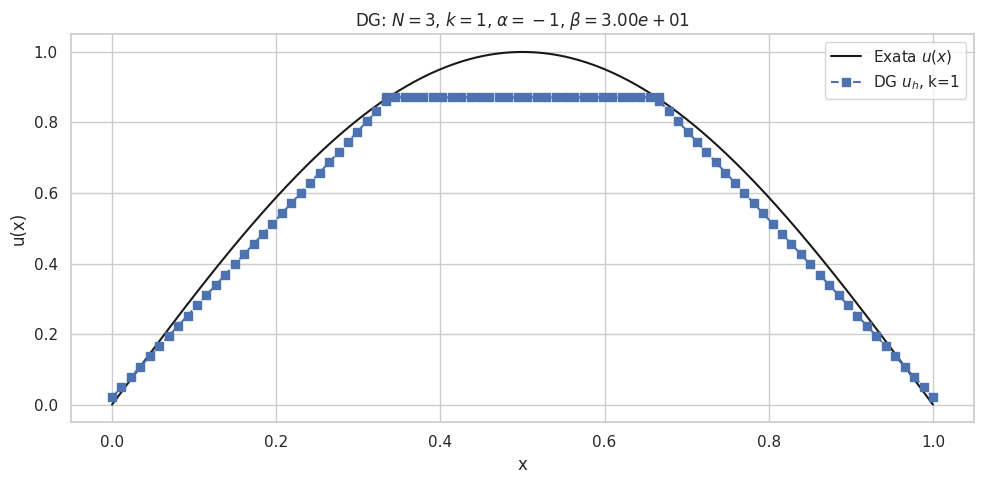

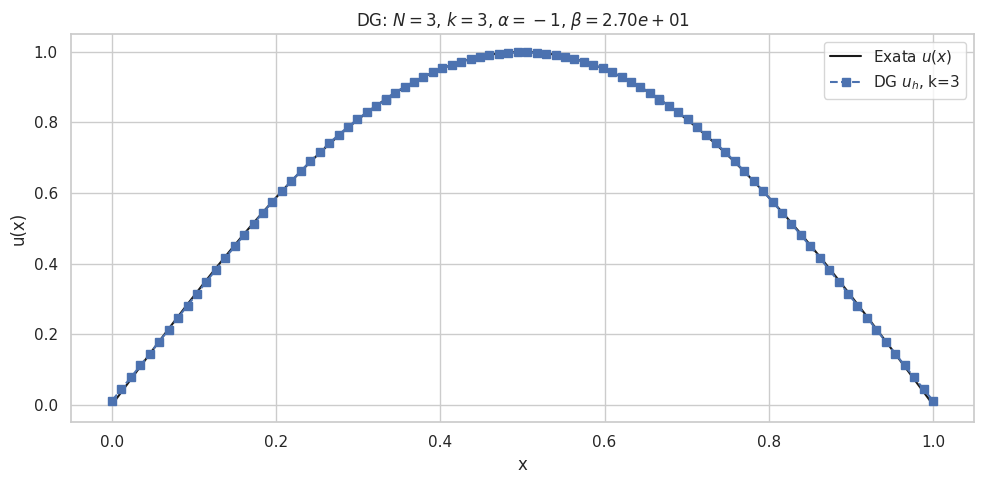

In [16]:
plot_dg_solution_test()
L = 1.0
n_elem = 3
k = 3
alpha = -1
beta0 = 1.0
plot_dg_solution_test(L, n_elem, k, alpha, beta0)



In [17]:
def convergence_study_g():
    L = 1.0
    beta0 = 10.0

    k_values = [1, 2, 3, 4]
    alpha_values = [-1, 0, 1]
    mesh_sizes = [4, 8, 16, 32]

    n_repeats = 3

    for alpha in alpha_values:
        history_hybrid = {
            k: {"h": [], "err": [], "time": []}
            for k in k_values
        }

        history_dg = {
            k: {"h": [], "err": [], "time": []}
            for k in k_values
        }

        print(f"\nLETRA (g) - HÍBRIDO vs DG alpha = {alpha}")
        print("-" * 125)
        print(
            f"{'Método':<10} | {'k':<3} | {'Nelem':<6} | {'h':<10} | "
            f"{'beta':<12} | {'Erro L2':<14} | {'Taxa':<8} | {'Tempo médio (s)':<16}"
        )
        print("-" * 125)

        for k in k_values:
            prev_h_hyb = None
            prev_err_hyb = None

            prev_h_dg = None
            prev_err_dg = None

            for n_elem in mesh_sizes:
                h = L / n_elem

                # ==========================
                # Método híbrido
                # ==========================
                times_hyb = []

                for _ in range(n_repeats):
                    t0 = time.perf_counter()

                    nodes_hyb, elements_hyb, lambda_app, u_hyb, K_lambda, beta_hyb = solve_hybrid_static_condensation(
                        L,
                        n_elem,
                        k,
                        alpha,
                        beta0
                    )

                    t1 = time.perf_counter()
                    times_hyb.append(t1 - t0)

                time_hyb = np.mean(times_hyb)

                err_hyb = compute_L2_error_hybrid(
                    nodes_hyb,
                    elements_hyb,
                    u_hyb,
                    k
                )

                rate_hyb = 0.0

                if prev_h_hyb is not None:
                    rate_hyb = np.log(prev_err_hyb / err_hyb) / np.log(prev_h_hyb / h)

                print(
                    f"{'Híbrido':<10} | {k:<3} | {n_elem:<6} | {h:<10.4f} | "
                    f"{beta_hyb:<12.3e} | {err_hyb:<14.3e} | "
                    f"{rate_hyb:<8.2f} | {time_hyb:<16.6e}"
                )

                history_hybrid[k]["h"].append(h)
                history_hybrid[k]["err"].append(err_hyb)
                history_hybrid[k]["time"].append(time_hyb)

                prev_h_hyb = h
                prev_err_hyb = err_hyb

                # ==========================
                # Método DG
                # ==========================
                times_dg = []

                for _ in range(n_repeats):
                    t0 = time.perf_counter()

                    nodes_dg, elements_dg, u_dg, K_dg, beta_dg = solve_dg(
                        L,
                        n_elem,
                        k,
                        alpha,
                        beta0
                    )

                    t1 = time.perf_counter()
                    times_dg.append(t1 - t0)

                time_dg = np.mean(times_dg)

                err_dg = compute_L2_error_dg(
                    nodes_dg,
                    elements_dg,
                    u_dg,
                    k
                )

                rate_dg = 0.0

                if prev_h_dg is not None:
                    rate_dg = np.log(prev_err_dg / err_dg) / np.log(prev_h_dg / h)

                print(
                    f"{'DG':<10} | {k:<3} | {n_elem:<6} | {h:<10.4f} | "
                    f"{beta_dg:<12.3e} | {err_dg:<14.3e} | "
                    f"{rate_dg:<8.2f} | {time_dg:<16.6e}"
                )

                history_dg[k]["h"].append(h)
                history_dg[k]["err"].append(err_dg)
                history_dg[k]["time"].append(time_dg)

                prev_h_dg = h
                prev_err_dg = err_dg

            print("-" * 125)

        # ==========================
        # Plot do erro
        # ==========================
        plt.figure(figsize=(10, 7))

        markers = ['o', 's', '^', 'D']

        for i, k in enumerate(k_values):
            plt.loglog(
                history_hybrid[k]["h"],
                history_hybrid[k]["err"],
                marker=markers[i],
                linestyle='-',
                label=rf'Híbrido k={k}'
            )

            plt.loglog(
                history_dg[k]["h"],
                history_dg[k]["err"],
                marker=markers[i],
                linestyle='--',
                label=rf'DG k={k}'
            )

        plt.title(rf'Erro $L^2$ - Híbrido vs DG, $\alpha={alpha}$')
        plt.xlabel('Tamanho do elemento $h$')
        plt.ylabel(r'Erro $L^2(\Omega)$')
        plt.grid(True, which="both", ls="--", alpha=0.6)
        plt.legend(fontsize=9)

        plt.tight_layout()

        alpha_name = str(alpha).replace("-", "menos")
        plt.savefig(folder + f"trabalho2_letra_g_erro_alpha_{alpha_name}.pdf")
        plt.show()

        # ==========================
        # Plot do tempo
        # ==========================
        plt.figure(figsize=(10, 7))

        for i, k in enumerate(k_values):
            plt.loglog(
                history_hybrid[k]["h"],
                history_hybrid[k]["time"],
                marker=markers[i],
                linestyle='-',
                label=rf'Híbrido k={k}'
            )

            plt.loglog(
                history_dg[k]["h"],
                history_dg[k]["time"],
                marker=markers[i],
                linestyle='--',
                label=rf'DG k={k}'
            )

        plt.title(rf'Custo computacional - Híbrido vs DG, $\alpha={alpha}$')
        plt.xlabel('Tamanho do elemento $h$')
        plt.ylabel('Tempo médio de solução (s)')
        plt.grid(True, which="both", ls="--", alpha=0.6)
        plt.legend(fontsize=9)

        plt.tight_layout()
        plt.savefig(folder + f"letra_g_tempo_alpha_{alpha_name}.pdf")
        plt.show()


LETRA (g) - HÍBRIDO vs DG alpha = -1
-----------------------------------------------------------------------------------------------------------------------------
Método     | k   | Nelem  | h          | beta         | Erro L2        | Taxa     | Tempo médio (s) 
-----------------------------------------------------------------------------------------------------------------------------
Híbrido    | 1   | 4      | 0.2500     | 4.000e+01    | 2.171e-02      | 0.00     | 1.622377e-03    
DG         | 1   | 4      | 0.2500     | 4.000e+01    | 3.785e-02      | 0.00     | 9.667857e-04    
Híbrido    | 1   | 8      | 0.1250     | 8.000e+01    | 5.446e-03      | 1.99     | 1.841884e-03    
DG         | 1   | 8      | 0.1250     | 8.000e+01    | 9.842e-03      | 1.94     | 1.794711e-03    
Híbrido    | 1   | 16     | 0.0625     | 1.600e+02    | 1.363e-03      | 2.00     | 4.390128e-03    
DG         | 1   | 16     | 0.0625     | 1.600e+02    | 2.482e-03      | 1.99     | 5.705261e-03    
Híb

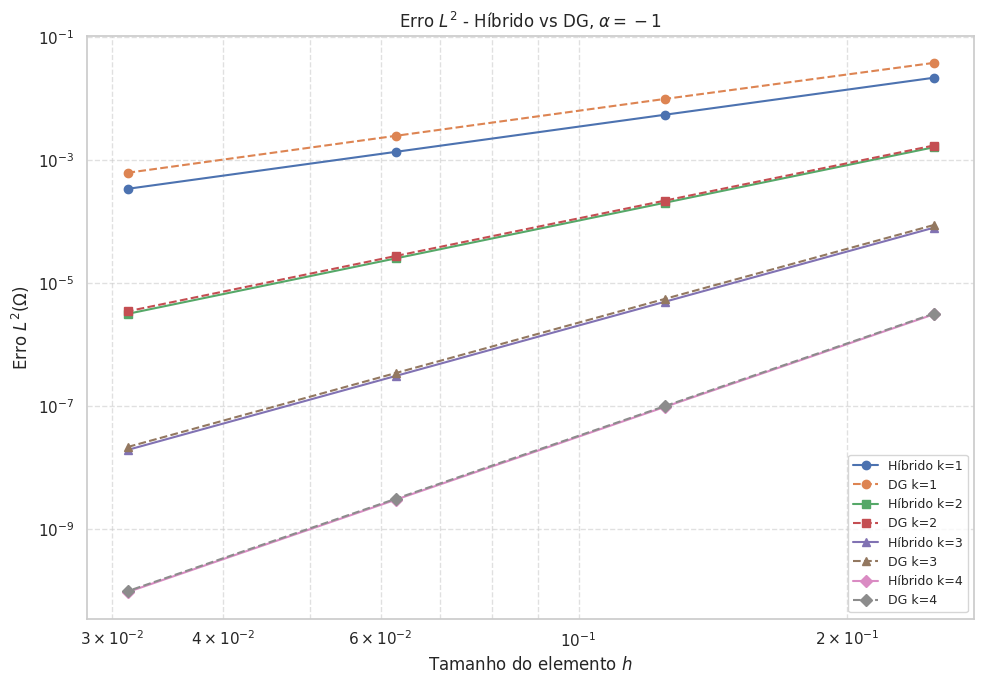

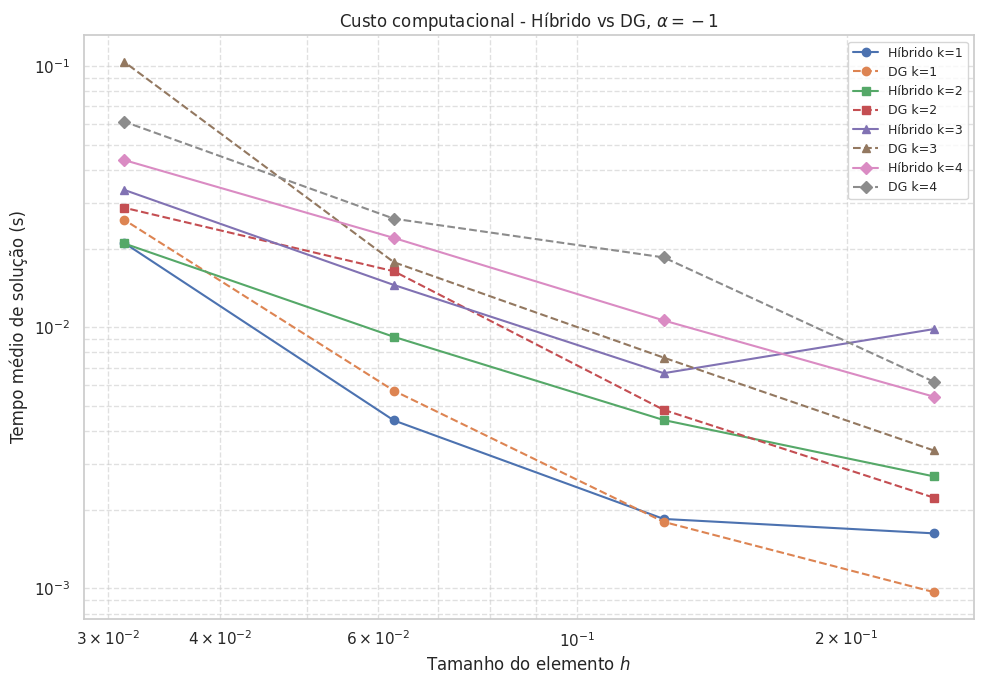


LETRA (g) - HÍBRIDO vs DG alpha = 0
-----------------------------------------------------------------------------------------------------------------------------
Método     | k   | Nelem  | h          | beta         | Erro L2        | Taxa     | Tempo médio (s) 
-----------------------------------------------------------------------------------------------------------------------------
Híbrido    | 1   | 4      | 0.2500     | 4.000e+01    | 2.678e-02      | 0.00     | 1.491955e-03    
DG         | 1   | 4      | 0.2500     | 4.000e+01    | 2.978e-02      | 0.00     | 1.304066e-03    
Híbrido    | 1   | 8      | 0.1250     | 8.000e+01    | 6.774e-03      | 1.98     | 2.219426e-03    
DG         | 1   | 8      | 0.1250     | 8.000e+01    | 7.908e-03      | 1.91     | 2.271232e-03    
Híbrido    | 1   | 16     | 0.0625     | 1.600e+02    | 1.698e-03      | 2.00     | 4.281693e-03    
DG         | 1   | 16     | 0.0625     | 1.600e+02    | 2.031e-03      | 1.96     | 5.447425e-03    
Híbr

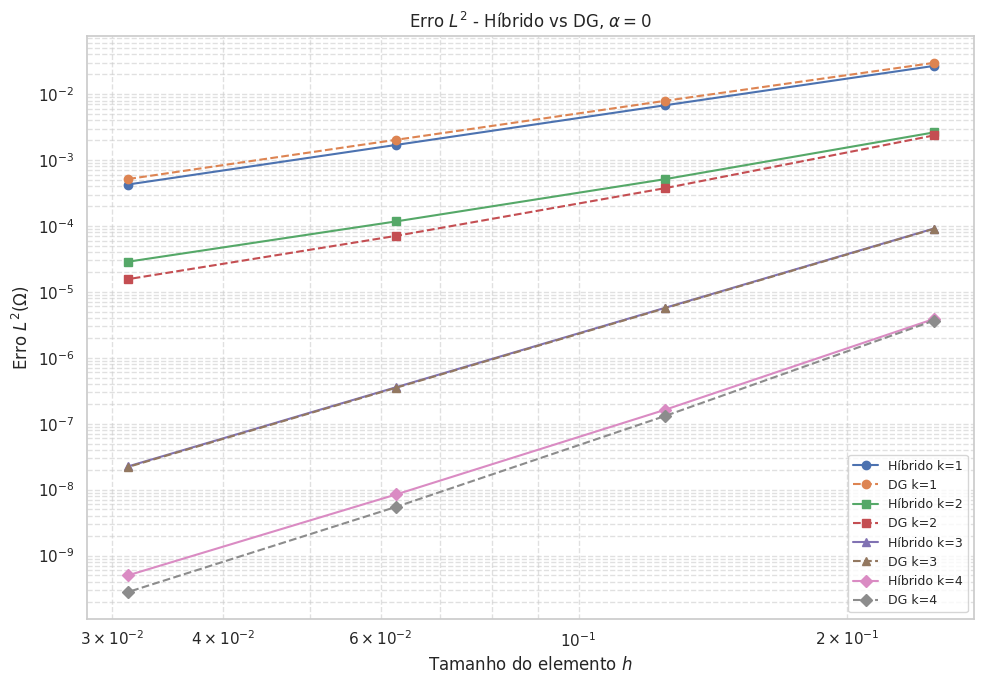

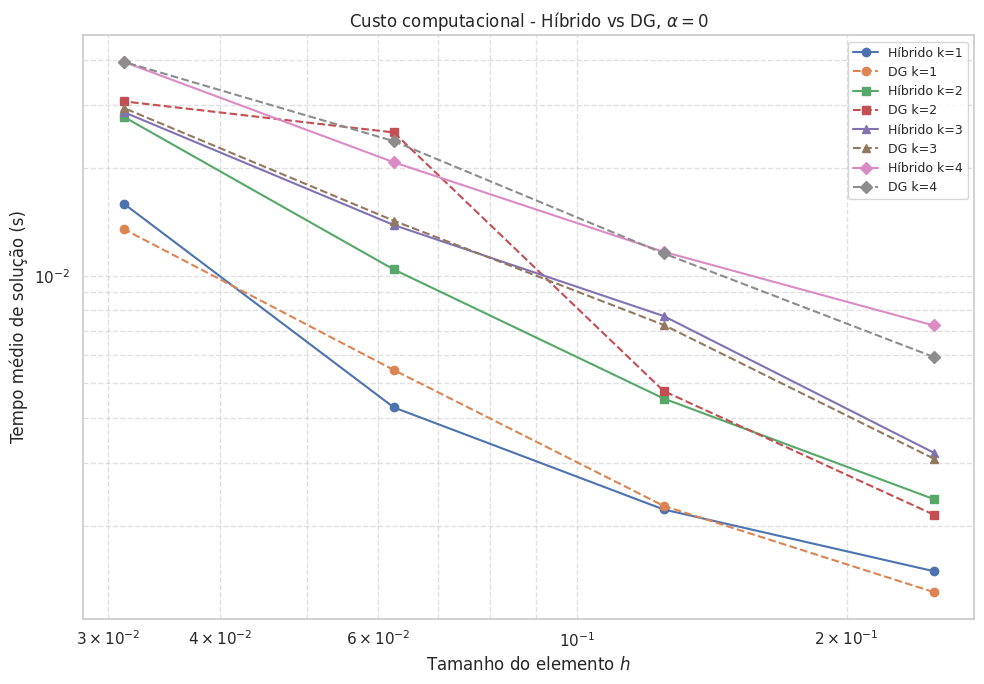


LETRA (g) - HÍBRIDO vs DG alpha = 1
-----------------------------------------------------------------------------------------------------------------------------
Método     | k   | Nelem  | h          | beta         | Erro L2        | Taxa     | Tempo médio (s) 
-----------------------------------------------------------------------------------------------------------------------------
Híbrido    | 1   | 4      | 0.2500     | 4.000e+01    | 3.061e-02      | 0.00     | 1.233434e-03    
DG         | 1   | 4      | 0.2500     | 4.000e+01    | 2.421e-02      | 0.00     | 9.914213e-04    
Híbrido    | 1   | 8      | 0.1250     | 8.000e+01    | 7.767e-03      | 1.98     | 1.906592e-03    
DG         | 1   | 8      | 0.1250     | 8.000e+01    | 6.518e-03      | 1.89     | 1.756436e-03    
Híbrido    | 1   | 16     | 0.0625     | 1.600e+02    | 1.949e-03      | 1.99     | 3.720394e-03    
DG         | 1   | 16     | 0.0625     | 1.600e+02    | 1.696e-03      | 1.94     | 5.348325e-03    
Híbr

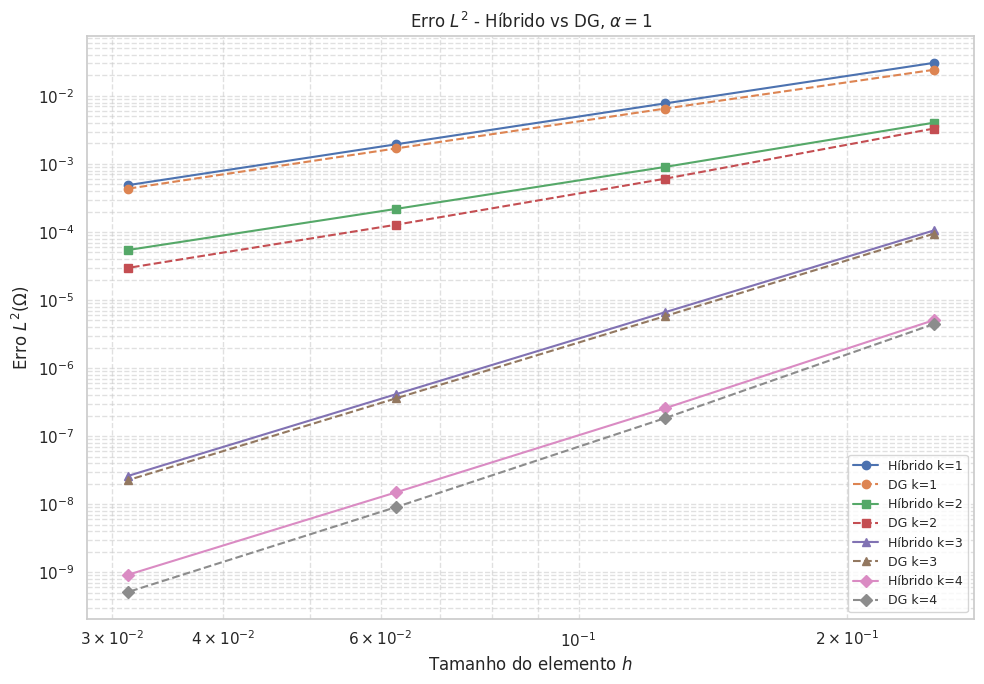

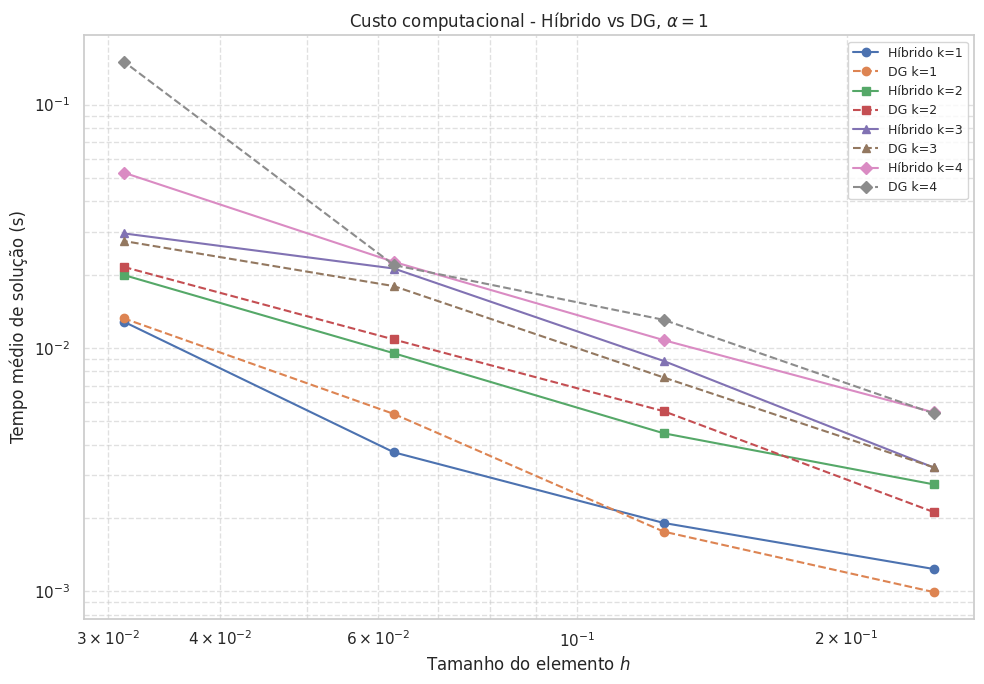

In [18]:
convergence_study_g()

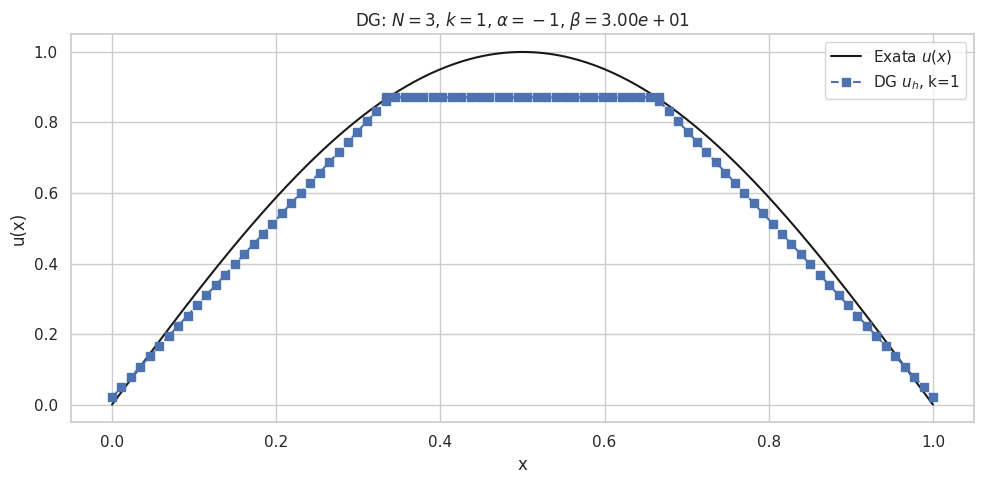

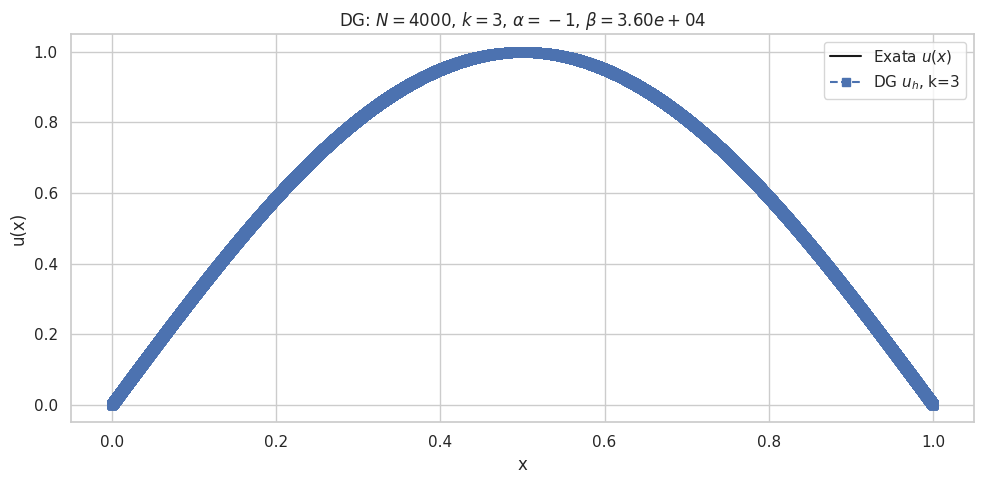

In [19]:
plot_dg_solution_test()
L = 1.0
n_elem = 4000
k = 3
alpha = -1
beta0 = 1.0
plot_dg_solution_test(L, n_elem, k, alpha, beta0)



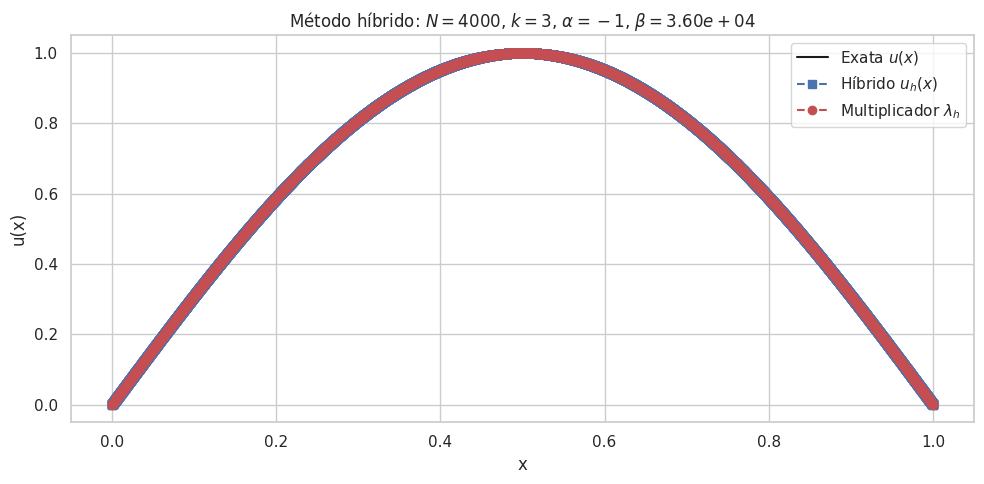

In [20]:
nodes_hyb, elements_hyb, lambda_app, u_hyb, K_lambda, beta = solve_hybrid_static_condensation(
    L,
    n_elem,
    k,
    -1,
    beta0
)

x_exact = np.linspace(0, L, 300)

x_hyb = []
u_hyb_plot = []

for elem_id, e in enumerate(elements_hyb):
    n1, n2 = e

    x1 = nodes_hyb[n1]
    x2 = nodes_hyb[n2]

    x_elem = np.linspace(x1, x2, k + 1)
    u_elem = u_hyb[elem_id, :]

    for i in range(k + 1):
        x_hyb.append(x_elem[i])
        u_hyb_plot.append(u_elem[i])

    # coloca nan para quebrar a linha entre elementos,
    # já que a solução híbrida é descontínua por elemento
    x_hyb.append(np.nan)
    u_hyb_plot.append(np.nan)

x_hyb = np.array(x_hyb)
u_hyb_plot = np.array(u_hyb_plot)

plt.figure(figsize=(10, 5))

plt.plot(x_exact, exact_u(x_exact), 'k-', label=r'Exata $u(x)$')
plt.plot(x_hyb, u_hyb_plot, 'bs--', label=r'Híbrido $u_h(x)$')
plt.plot(nodes_hyb, lambda_app, 'ro--', label=r'Multiplicador $\lambda_h$')

plt.title(rf'Método híbrido: $N={n_elem}$, $k={k}$, $\alpha=-1$, $\beta={beta:.2e}$')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(folder + f"teste_hibrido_N{n_elem}_k{k}_alpha_menos1.pdf")
plt.show()